In [1]:
import demes
import msprime
import numpy as np
import os

import h2py
from h2py.utils import timestamp

In [4]:
# Simulation parameters
L = 1_000_000
n_reps = 10
u = 1.5e-8
r = 1e-8
n_samples = 1
r_bins = np.logspace(-6, -2, 17)
pops = {"pop0": 1, "pop1": 1}
samples = ["tsk_0", "tsk_1"]
depth = 4

# File names
pop_file = "data/populations.txt"
rec_map_file = "data/rec_map.txt"
bed_file = "data/coverage.bed"


def demographic_model():
    b = demes.Builder()
    b.add_deme("pop0", epochs=[dict(start_size=1e4, end_time=0)])
    b.add_deme("pop1", ancestors=["pop0"], start_time=1e4,
               epochs=[dict(start_size=1e4, end_time=0)])
    g = b.resolve()
    return g


g = demographic_model()

In [5]:
def write_pop_file():
    with open(pop_file, "w") as fout:
        fout.write("sample\tpop\n")
        idx = 0
        for pop in samples:
            for sidx in range(n_samples):
                fout.write(f"tsk_{idx}\t{pop}\n")
                idx += 1


def write_rec_map_file():
    with open(rec_map_file, "w") as fout:
        fout.write("chrom\tPosition(bp)\tMap(cM)\n")
        fout.write("none\t0\t0\n")
        fout.write(f"none\t{L}\t{100*r*L}\n")


def write_bed_file():
    with open(bed_file, "w") as fout:
        fout.write(f"none\t0\t{L}\n")


write_pop_file()
write_rec_map_file()
write_bed_file()

In [6]:
def run_sim(g, i):
    demog = msprime.Demography.from_demes(g)
    ts = msprime.sim_ancestry(
        pops,
        demography=demog,
        sequence_length=L,
        recombination_rate=r,
    )
    ts = msprime.sim_mutations(ts, rate=u, model="binary")
    ref_seq = h2py.simulation.generate_sam_files(
            ts,
            samples,
            f"data/{{sample}}.{i}.sam",
            depth=depth,
            ref_name="reference",
            report=100000,
        )
    fasta_file = f"data/reference.{i}.fasta"
    h2py.utils.write_fasta_file(fasta_file, [ref_seq], ["reference"])
    print(timestamp(), f"Simulated replicate {i}")

for i in range(n_reps):
    run_sim(g, i)

[26-07-17 13:34:04] Wrote read 0; depth 6.7e-05
[26-07-17 13:34:06] Wrote read 79999; depth 3.997414
[26-07-17 13:34:06] Finished writing data/tsk_0.0.sam
[26-07-17 13:34:06] Wrote read 0; depth 8.9e-05
[26-07-17 13:34:08] Wrote read 79999; depth 3.995805
[26-07-17 13:34:08] Finished writing data/tsk_1.0.sam
[26-07-17 13:34:08] Simulated replicate 0
[26-07-17 13:34:08] Wrote read 0; depth 7.7e-05
[26-07-17 13:34:10] Wrote read 79999; depth 3.989856
[26-07-17 13:34:10] Finished writing data/tsk_0.1.sam
[26-07-17 13:34:10] Wrote read 0; depth 5.1e-05
[26-07-17 13:34:12] Wrote read 79999; depth 3.998633
[26-07-17 13:34:12] Finished writing data/tsk_1.1.sam
[26-07-17 13:34:12] Simulated replicate 1
[26-07-17 13:34:12] Wrote read 0; depth 5.2e-05
[26-07-17 13:34:14] Wrote read 79999; depth 3.996489
[26-07-17 13:34:14] Finished writing data/tsk_0.2.sam
[26-07-17 13:34:14] Wrote read 0; depth 5.9e-05
[26-07-17 13:34:16] Wrote read 79999; depth 3.997412
[26-07-17 13:34:16] Finished writing dat

In [7]:
# Use ATLAS to compute genotype probabilities
for i in range(n_reps):
    for sample in samples:
        !samtools view -b "data/{sample}.{i}.sam" | samtools sort -o "data/{sample}.{i}.bam"
        !atlas call --bam "data/{sample}.{i}.bam" --fasta "data/reference.{i}.fasta" --method Bayesian \
            --sampleName "{sample}" --out "data/{sample}.{i}" --noTriallelic

        !gzip -d "data/{sample}.{i}_calls_maximumAPosteriori.vcf.gz"
        !bgzip "data/{sample}.{i}_calls_maximumAPosteriori.vcf"
        !bcftools index "data/{sample}.{i}_calls_maximumAPosteriori.vcf.gz"

    args = " ".join([f"data/{sample}.{i}_calls_maximumAPosteriori.vcf.gz" for sample in samples])
    !bcftools merge -o "data/mergedGPs.{i}.vcf.gz" {args}

atlas: /lib/x86_64-linux-gnu/libhts.so.3: no version information available (required by atlas)

                   ATLAS 2.0.3
                  -------------

     https://bitbucket.org/wegmannlab/atlas

 Commit 7ab31971feabf9a9fd07409cedcc56d1b86e2d4d

   - Used executable: atlas
   - Interpreting 'call' as name of task.
   - Will write log to file 'data/tsk_0.0.log'. (use 'noLogFile' to supress or 'logFile' to specify the file-name)
   - Calling genotypes (task = call):
      - Writing output files with prefix 'data/tsk_0.0'. (parameter 'out')
      - Initializing random generator with seed 1'784'313'285'944. (use 'fixedSeed' or 'addToSeed' to specify)
      - Will use the following filters on reads:
         - Mapped length: restrict to range [0,500]. (parameter 'filterMappingLength')
         - Read length: keep all. (use 'filterReadLength' to limit)
         - Mapping quality: keep all. (use 'filterMQ' to limit)
         - Fragment length: keep all. (use 'filterFragmentLength' to

[26-07-17 13:37:04] Preparing data ...
[26-07-17 13:37:10] Prepared GenotypeProbMatrix (456463 sites, 2 samples, 2 pops)
[26-07-17 13:37:10] Loaded map coordinates (1.5e-07 to 0.01 M)
[26-07-17 13:37:10] Computing statistics and denominators ...
[26-07-17 13:37:11] Computed statistics and denominators.
[26-07-17 13:37:11]     Done!
[26-07-17 13:37:11] Preparing data ...
[26-07-17 13:37:17] Prepared GenotypeProbMatrix (515632 sites, 2 samples, 2 pops)
[26-07-17 13:37:17] Loaded map coordinates (1e-08 to 0.01 M)
[26-07-17 13:37:17] Computing statistics and denominators ...
[26-07-17 13:37:18] Computed statistics and denominators.
[26-07-17 13:37:18]     Done!
[26-07-17 13:37:18] Preparing data ...
[26-07-17 13:37:23] Prepared GenotypeProbMatrix (397143 sites, 2 samples, 2 pops)
[26-07-17 13:37:23] Loaded map coordinates (1e-08 to 0.01 M)
[26-07-17 13:37:23] Computing statistics and denominators ...
[26-07-17 13:37:24] Computed statistics and denominators.
[26-07-17 13:37:24]     Done!
[2

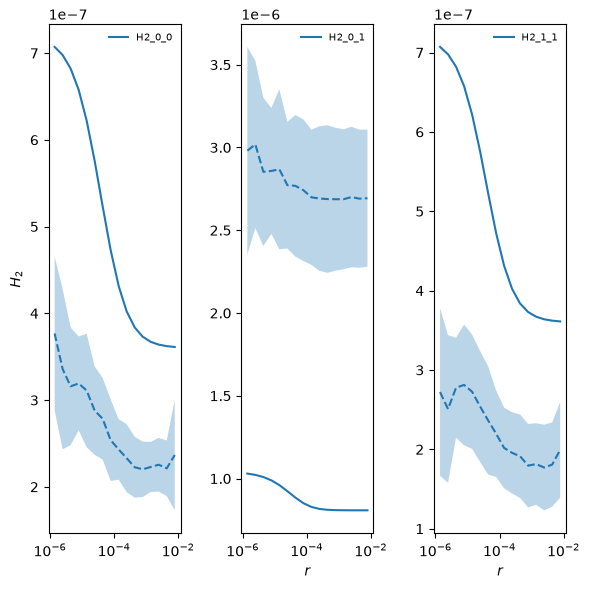

[0.00047675 0.00165523 0.00042898]
[0.0006 0.0009 0.0006]


In [8]:
sums = {}
for i in range(n_reps):
    sums[i] = h2py.parsing.compute_h2_stats(
        vcf_file=f"data/mergedGPs.{i}.vcf.gz",
        use_genotype_probs=True,
        pop_file=pop_file,
        bed_file=bed_file,
        rec_map_file=rec_map_file,
        r_bins=r_bins,
        report=True,
    )
boot_data = h2py.parsing.bootstrap_data(sums)
model = h2py.H2stats.from_demes(g, sampled_demes=["pop0", "pop1"], u=u, r_bins=r_bins)
h2py.plotting.plot_h2_curves_comp(
    model,
    boot_data["means"],
    boot_data["varcovs"],
    r_bins=r_bins,
)

print(boot_data["means"][-1])
print(model.data[-1])